# Firing rate maps (per-trajectory, not pooled)

Computes occupancy and firing-rate maps for one neuron at a time, separately for each of the 50 trajectories.

Design notes (fixes vs. the original pipeline):
- Occupancy map and firing-rate map are built with the *same* `np.histogram2d` call signature (same `bins`, same fixed `range`), so they always land on an identical grid — no separate meshgrid/nearest-bin search, no row/column mismatch possible.
- Bin edges are pinned explicitly to the known trajectory bounds `[0, 1] x [0, 1]` via `range=`, instead of being derived from each call's own data min/max — every trajectory's map is on the exact same physical grid, so maps are directly comparable across trials.
- No `rotate()` calls anywhere. The only reorientation is a single `.T` + `origin='lower'` applied consistently at plot time (see `plot_random_trajectory_maps`), so there's nothing that can drift out of sync between maps.
- Activation values are converted to amplitude (`np.abs`) before binning, so complex-valued activity from the oscillatory network is handled explicitly rather than silently truncated by an implicit complex-to-real cast.
- Firing rate = occupancy-weighted mean amplitude per bin (a spatial average), not a threshold-then-peak value — avoids an arbitrary spike threshold and matches how rate maps are usually computed for continuous-valued unit activity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import gaussian_filter
import scipy.signal


In [2]:
# Trajectory grid bounds and map resolution.
# 1000 points per trajectory / 32x32 bins ~= 1 raw sample per bin before smoothing —
# fine enough to resolve field structure without every bin being empty.
BOUNDS = (0.0, 1.0)
N_BINS = 40
SIGMA = 0.5     # Gaussian smoothing bandwidth, in bins
EPS = 1e-12

SKIP_TIMESTEPS = 50


SI_THRESHOLD = 0
SPARSITY_THRESHOLD = 0


### Input

In [3]:
def get_input_data(
    pkl_path,
    layer_name,
    representation="auto",
):
    """
    representation:
        auto      -> real layers stay real,
                     complex layers -> magnitude

        real      -> real(z)

        imag      -> imag(z)

        magnitude -> |z|

        phase     -> angle(z)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction   = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    if ground_truth.shape[-1] > 2:
        ground_truth = ground_truth[..., :2]

    if prediction.shape[-1] > 2:
        prediction = prediction[..., :2]

    # ----------------------------------------
    # Choose representation
    # ----------------------------------------

    if np.iscomplexobj(activations):

        if representation == "auto":
            activations = np.abs(activations)

        elif representation == "magnitude":
            activations = np.abs(activations)

        elif representation == "phase":
            activations = np.angle(activations)

        elif representation == "real":
            activations = activations.real

        elif representation == "imag":
            activations = activations.imag

        else:
            raise ValueError("Unknown representation")

    # ----------------------------------------
    # Skip burn-in
    # ----------------------------------------

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]
        prediction   = prediction[:, SKIP_TIMESTEPS:, :]
        activations  = activations[:, SKIP_TIMESTEPS:, :]

    positions = prediction.copy()

    return ground_truth, prediction, positions, activations

### Mapping functions

In [4]:
def occupancy_map_func(positions, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA):
    '''
    positions: (T, 2) single trajectory.
    Returns a smoothed occupancy-count map, shape (bins, bins), axis 0 = x-bin, axis 1 = y-bin.
    '''
    H, xedges, yedges = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds]
    )
    occupancy = gaussian_filter(H, sigma=sigma, mode='nearest', cval=0.0)
    #occupancy = H
    return occupancy, xedges, yedges

In [5]:
def firing_rate_map_func(positions, activity, occupancy_map, bins=N_BINS, bounds=BOUNDS,
                          sigma=SIGMA, eps=EPS, min_occupancy=None):
    

    activity = np.maximum(activity, 0)

    # remove baseline firing
    activity = activity - activity.mean()

    # keep only above-baseline activity
    activity = np.maximum(activity, 0)
    

    amplitude = activity

    activity_sum, _, _ = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds],
        weights=amplitude
    )
    
    activity_sum = gaussian_filter(activity_sum, sigma=sigma, mode='nearest', cval=0.0)
    
    occupancy_map = gaussian_filter(occupancy_map, sigma=0, mode='nearest', cval=0.0)  # already smoothed upstream — don't double-smooth

    rate_map = activity_sum / (occupancy_map + eps)

    #rate_map = gaussian_filter(rate_map, sigma=sigma, mode='nearest', cval=0.0)

    if min_occupancy is not None:
        rate_map = np.where(occupancy_map < min_occupancy, np.nan, rate_map)

    return rate_map

### Plotting

In [6]:
def spatial_information(rate_map, occupancy_map):
    valid = (~np.isnan(rate_map)) & (occupancy_map > 0)
    p = occupancy_map[valid] / occupancy_map[valid].sum()
    r = rate_map[valid]
    r_bar = np.sum(p * r)
    if r_bar <= 0:
        return 0.0
    ratio = r / r_bar

    info_terms = np.zeros_like(r)

    positive = ratio > 0

    info_terms[positive] = (p[positive] * ratio[positive] * np.log2(ratio[positive]))

    return np.sum(info_terms)


def sparsity(rate_map, occupancy_map):
    valid = (~np.isnan(rate_map)) & (occupancy_map > 0)
    p = occupancy_map[valid] / occupancy_map[valid].sum()
    r = rate_map[valid]
    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r ** 2)
    if mean_r2 <= EPS:
        return np.nan
    return (mean_r ** 2) / mean_r2

In [7]:
# ==========================================================
# VISUALIZE ONE NEURON
# ==========================================================

def visualize_neuron(neuron_idx, rectify=True):

    # --------------------------------------------
    # Get activity
    # --------------------------------------------

    activity = activations_all[:, neuron_idx].copy()

    # Only rectify amplitude-like representations
    if rectify:
        activity = np.maximum(activity, 0)

    # --------------------------------------------
    # Rate map
    # --------------------------------------------

    rate_map = firing_rate_map_func(
        positions_all,
        activity,
        occupancy_map,
        bins=N_BINS,
        bounds=BOUNDS,
        sigma=SIGMA,
        eps=EPS,
    )

    # --------------------------------------------
    # Metrics
    # --------------------------------------------

    si = spatial_information(rate_map, occupancy_map)
    sp = sparsity(rate_map, occupancy_map)

    # --------------------------------------------
    # Normalize activity for plotting
    # --------------------------------------------

    activity_min = activity.min()
    activity_max = activity.max()

    activity_norm = (
        activity - activity_min
    ) / (activity_max - activity_min + 1e-12)

    sizes = 2 + 10 * activity_norm

    # --------------------------------------------
    # Figure
    # --------------------------------------------

    fig, ax = plt.subplots(1,4,figsize=(22,5))

    # ======================================================
    # Combined trajectory
    # ======================================================

    ax[0].plot(
        positions_all[:,0],
        positions_all[:,1],
        color="black",
        lw=0.15,
    )

    ax[0].set_title("Combined Trajectory")
    ax[0].set_xlim(0,1)
    ax[0].set_ylim(0,1)
    ax[0].set_aspect("equal")

    # ======================================================
    # Occupancy
    # ======================================================

    im_occ = ax[1].imshow(
        occupancy_map.T,
        origin="lower",
        extent=[0,1,0,1],
        cmap="viridis",
    )

    ax[1].set_title("Occupancy Map")
    ax[1].set_aspect("equal")

    plt.colorbar(im_occ, ax=ax[1], fraction=0.046)

    # ======================================================
    # Activity
    # ======================================================

    sc = ax[2].scatter(
        positions_all[:,0],
        positions_all[:,1],
        c=activity_norm,
        s=sizes,
        cmap="twilight" if not rectify else "jet",
        linewidths=0,
        alpha=0.75,
    )

    ax[2].set_xlim(0,1)
    ax[2].set_ylim(0,1)
    ax[2].set_aspect("equal")

    ax[2].set_title(
        f"Neuron {neuron_idx}\n"
        f"SI={si:.3f}  Sparsity={sp:.3f}"
    )

    plt.colorbar(
        sc,
        ax=ax[2],
        fraction=0.046,
        label="Normalized Activity",
    )

    # ======================================================
    # Rate map
    # ======================================================

    im_rate = ax[3].imshow(
        rate_map.T,
        origin="lower",
        extent=[0,1,0,1],
        cmap="twilight" if not rectify else "jet",
    )

    ax[3].set_title("Firing Rate Map")
    ax[3].set_aspect("equal")

    plt.colorbar(
        im_rate,
        ax=ax[3],
        fraction=0.046,
        label="Rate",
    )

    plt.tight_layout()
    plt.show()

    return si, sp

### Example usage

In [10]:


pkl_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

layer_name = "z3"
representation = "phase"

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name,
    representation=representation,
)


print("Ground truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)


Ground truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [11]:
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Plot one neuron on two trajectories
# ==========================================================

def plot_neuron_two_trajs(neuron,
                          traj1,
                          traj2,
                          rectify=True):

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    traj_indices = [traj1, traj2]

    for k, traj in enumerate(traj_indices):

        pos = positions[traj]          # (T,2)
        activity = activations[traj, :, neuron].copy()

        if rectify:
            activity = np.maximum(activity, 0)

        # normalize for colour
        activity_norm = (
            activity - activity.min()
        ) / (activity.max() - activity.min() + 1e-12)

        # line segments
        points = pos.reshape(-1,1,2)
        segments = np.concatenate(
            [points[:-1], points[1:]],
            axis=1
        )

        lc = LineCollection(
            segments,
            cmap="jet",
            linewidth=2
        )

        lc.set_array(activity_norm[:-1])

        ax[k].add_collection(lc)

        ax[k].set_xlim(0,1)
        ax[k].set_ylim(0,1)
        ax[k].set_aspect("equal")

        ax[k].set_title(
            f"Neuron {neuron}\nTrajectory {traj}"
        )

        plt.colorbar(
            lc,
            ax=ax[k],
            fraction=0.046,
            label="Normalized activity"
        )

    plt.tight_layout()
    plt.show()

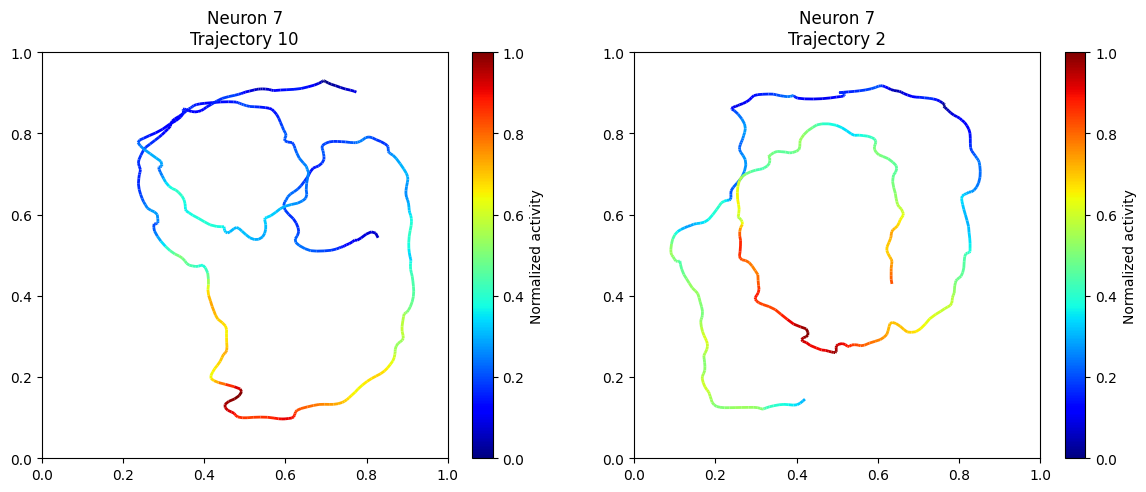

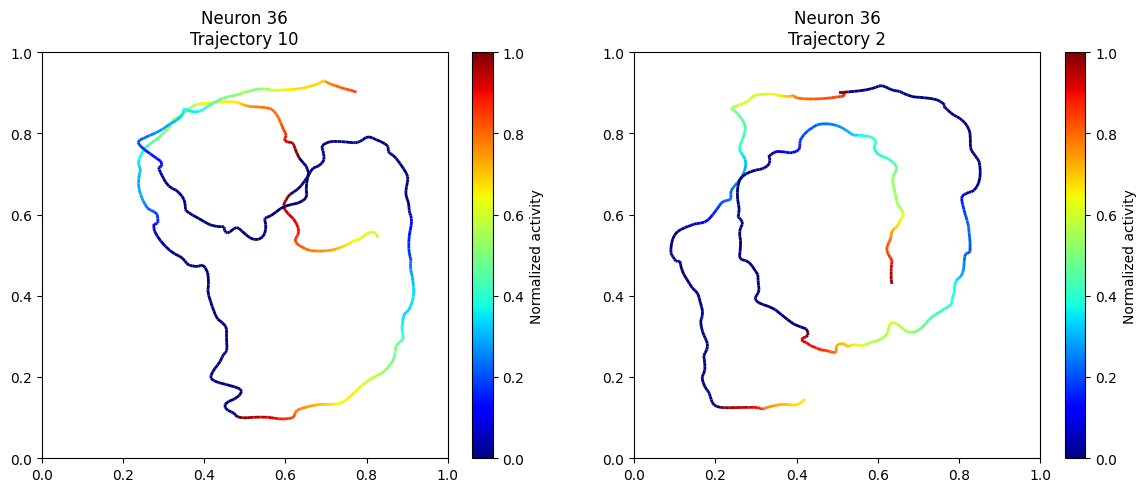

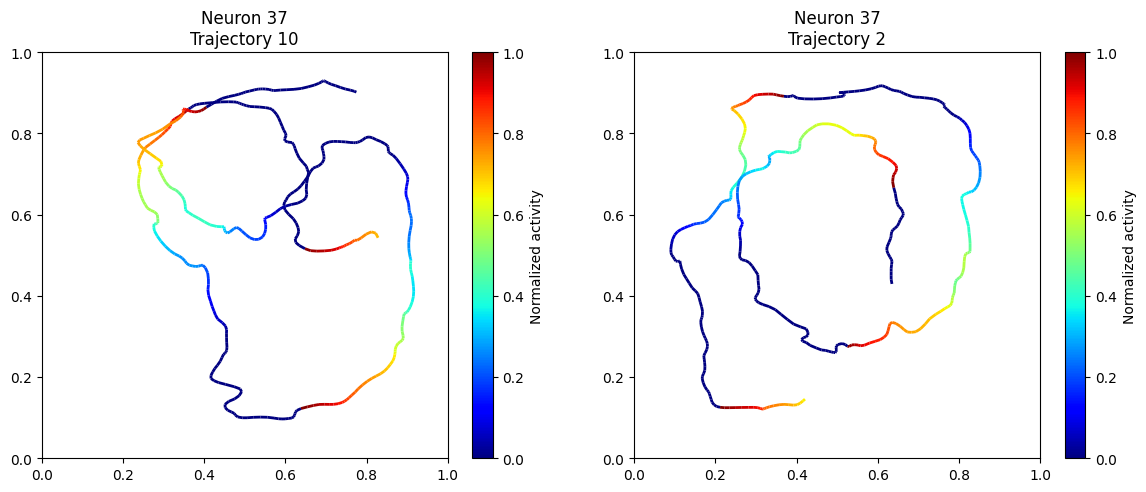

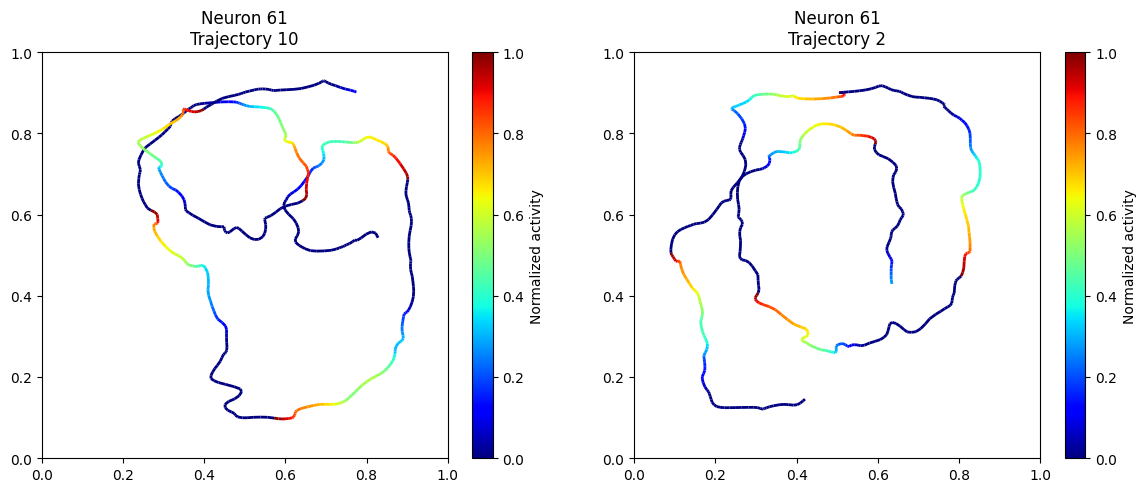

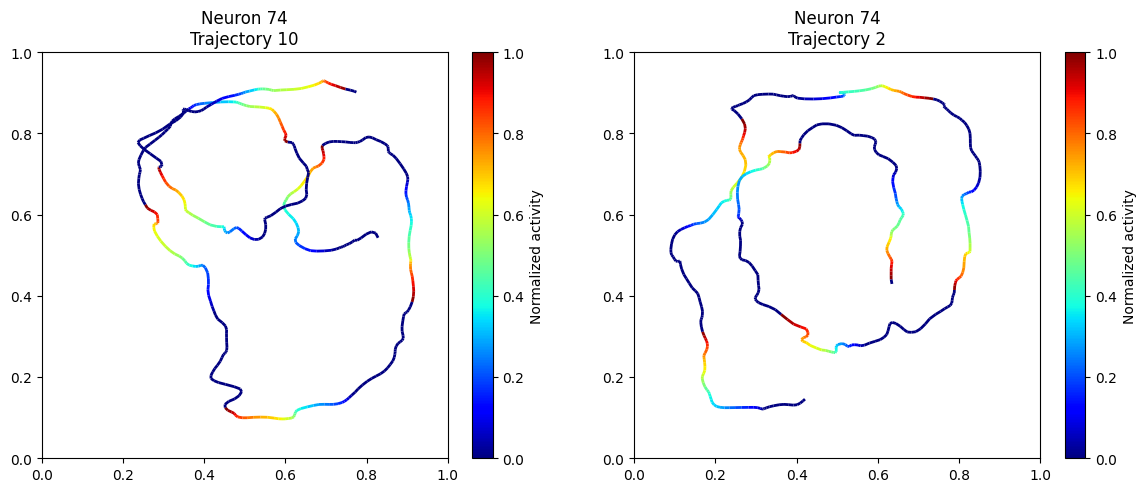

In [15]:
TRAJ1 = 10
TRAJ2 = 2

interesting = [7, 36, 37, 61, 74]

for neuron in interesting:
    plot_neuron_two_trajs(
        neuron,
        TRAJ1,
        TRAJ2,
        rectify=True
    )